# 05 · Análisis de resultados

Lee los resultados guardados por los notebooks 02 y 04 (no reentrena
nada) y construye las tablas/gráficas finales para el README y la
presentación: ¿mejora el predictor al añadir historia sintética?, ¿qué
generador funciona mejor?, ¿coincide con qué generador preserva mejor la
distribución conjunta real (notebook 02)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, plotting as pl

## 1. Cargar resultados

In [2]:
results = pd.read_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
corr_quality = pd.read_csv(config.TABLES_DIR / "02_calidad_correlacion_generadores.csv", index_col=0)
empalme = pd.read_csv(config.TABLES_DIR / "03_continuidad_empalme.csv", index_col=0)
results.head()

,Unnamed: 0,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
0,0,solo_reales,0,252,0.000000,0.000251,0.011792,0.511475
1,1,gan,7,2013,0.874814,0.000253,0.011826,0.530164
2,2,gaussian,7,2013,0.874814,0.000256,0.011926,0.521311
3,3,noise,7,2013,0.874814,0.000254,0.011858,0.528852
4,4,rbig,7,2013,0.874814,0.000255,0.011898,0.521967


## 2. Tabla final: MAE/MSE por generador y años de backfill sintético
   añadidos, con mejora relativa frente a "solo reales" (`synth_years=0`)

In [3]:
pivot_mae = results.pivot_table(index="synth_years", columns="generator", values="mae")
baseline_mae = results.loc[results["generator"] == "solo_reales", "mae"].iloc[0]
mejora_pct = (baseline_mae - pivot_mae) / baseline_mae * 100

pivot_mae.to_csv(config.TABLES_DIR / "05_tabla_mae_final.csv")
mejora_pct.to_csv(config.TABLES_DIR / "05_tabla_mejora_pct.csv")
print(f"MAE de referencia (solo la ventana real disponible para entrenar, ~1 año, sin sintéticos): {baseline_mae:.5f}")
pivot_mae.round(5)

MAE de referencia (solo la ventana real disponible para entrenar, ~1 año, sin sintéticos): 0.01179


generator,gan,gaussian,noise,rbig,solo_reales
synth_years,,,,,
0,NaN,NaN,NaN,NaN,0.01179
7,0.01183,0.01193,0.01186,0.01190,NaN
14,0.01187,0.01182,0.01184,0.01183,NaN
21,0.01179,0.01181,0.01179,0.01176,NaN
28,0.01177,0.01186,0.01177,0.01178,NaN


In [4]:
mejora_pct.round(1)

generator,gan,gaussian,noise,rbig,solo_reales
synth_years,,,,,
0,NaN,NaN,NaN,NaN,0.0
7,-0.3,-1.1,-0.6,-0.9,NaN
14,-0.6,-0.2,-0.4,-0.3,NaN
21,-0.0,-0.2,0.0,0.3,NaN
28,0.2,-0.6,0.2,0.1,NaN


## 3. ¿Mejora el predictor al añadir historia sintética?

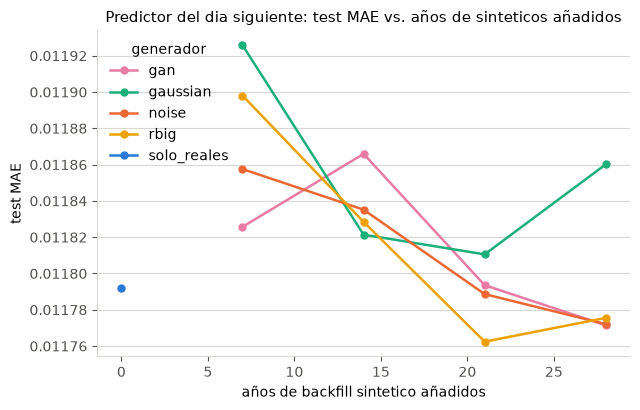

In [5]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "05_resultado_final_mae")
plt.show()

## 4. Mejor generador a máxima profundidad sintética vs. calidad de
   reconstrucción de la distribución conjunta (notebook 02)

Si el generador que MEJOR reproduce la distribución conjunta real
(`dist_frobenius_corr` más bajo) es también el que da mejor MAE final, es
una señal fuerte de que la calidad del generador —y no solo la cantidad
de datos sintéticos— importa.

In [6]:
synth_max = results["synth_years"].max()
final_depth = (
    results[results["synth_years"] == synth_max]
    .set_index("generator")[["mae", "mse", "pct_synth"]]
    .join(corr_quality, how="left")
    .sort_values("mae")
)
final_depth.to_csv(config.TABLES_DIR / "05_tabla_generador_final.csv")
final_depth

,mae,mse,pct_synth,dist_frobenius_corr
generator,,,,
gan,0.011771,0.000250,0.964397,1.197853
noise,0.011772,0.000250,0.964397,0.385964
rbig,0.011776,0.000250,0.964397,0.479580
gaussian,0.011860,0.000253,0.964397,0.403699


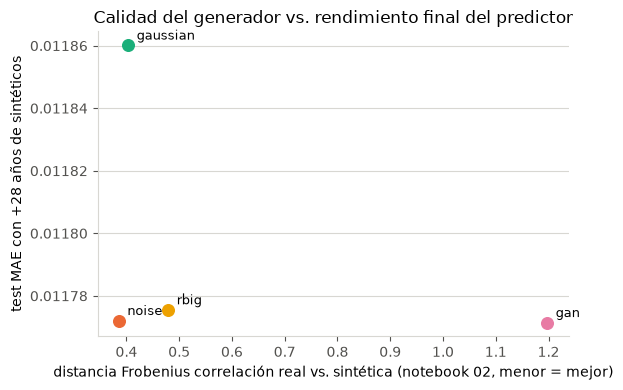

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, row in final_depth.iterrows():
    ax.scatter(row["dist_frobenius_corr"], row["mae"], s=70, color=pl.color_for(name), label=name)
    ax.annotate(name, (row["dist_frobenius_corr"], row["mae"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.set_xlabel("distancia Frobenius correlación real vs. sintética (notebook 02, menor = mejor)")
ax.set_ylabel(f"test MAE con +{synth_max} años de sintéticos")
ax.set_title("Calidad del generador vs. rendimiento final del predictor")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "05_calidad_generador_vs_mae")
plt.show()

## 5. Precisión direccional (¿acierta el signo del retorno?) y desglose
   por banco

El MAE mide error de MAGNITUD; para un "predictor de precios" también
importa si acierta la DIRECCIÓN (sube/baja) — 0.5 = tan bueno como una
moneda. Y el MAE por banco (notebook 04, misma idea que el bloque final
de `Taller_con_Datos_SP500_promedio.ipynb`) evita que la comparación
quede dominada por los bancos de mayor volatilidad (ver notebook 01).

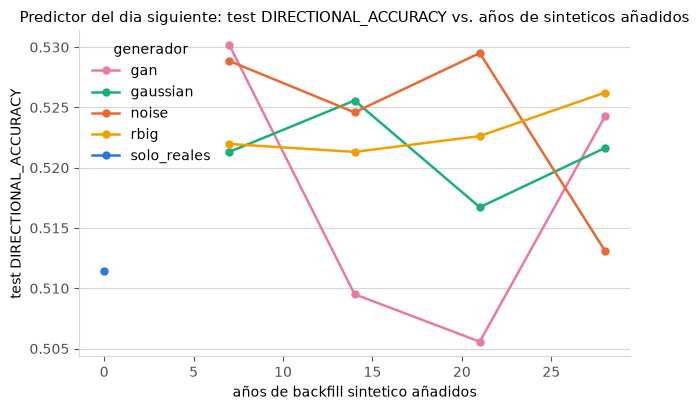

In [8]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "05_precision_direccional")
plt.show()

In [9]:
mae_por_banco = pd.read_csv(config.TABLES_DIR / "04_mae_por_banco.csv", index_col=0)
mae_por_banco.round(5)

,noise,gaussian,rbig,gan,solo_reales
ticker,,,,,
BAC,0.01105,0.01104,0.01101,0.01105,0.01097
WFC,0.01372,0.01378,0.01373,0.01373,0.01371
JPM,0.01161,0.01166,0.01160,0.01160,0.01161
C,0.01495,0.01494,0.01497,0.01497,0.01485
HBAN,0.01333,0.01340,0.01332,0.01334,0.01335
USB,0.01080,0.01090,0.01076,0.01079,0.01076
TFC,0.01146,0.01169,0.01149,0.01145,0.01148
KEY,0.01173,0.01180,0.01175,0.01174,0.01179
RF,0.01198,0.01212,0.01198,0.01196,0.01201


## 6. Continuidad del empalme real/sintético por generador (notebook 03)

In [10]:
empalme.round(3)

,mean,std
generador,,
gan,2.429,0.263
gaussian,1.279,0.160
noise,1.242,0.114
rbig,1.244,0.121


## 7. Resumen para el README / presentación

Esta celda imprime, en texto, el resumen que debe copiarse (o citarse) en
el README y en las diapositivas de resultados.

In [11]:
mejor_generador = final_depth["mae"].idxmin()
mejora_mejor = mejora_pct.loc[synth_max, mejor_generador]
print(
    f"- MAE solo con la ventana real (sin sintéticos): {baseline_mae:.5f}\n"
    f"- Mejor generador con +{synth_max} años de sintéticos: {mejor_generador} "
    f"(MAE {final_depth.loc[mejor_generador, 'mae']:.5f}, "
    f"{mejora_mejor:+.1f}% vs. solo reales)\n"
    f"- % de días con volatilidad sintética con +{synth_max} años añadidos: "
    f"{final_depth.loc[mejor_generador, 'pct_synth']:.1%}\n"
)

- MAE solo con la ventana real (sin sintéticos): 0.01179
- Mejor generador con +28 años de sintéticos: gan (MAE 0.01177, +0.2% vs. solo reales)
- % de días con volatilidad sintética con +28 años añadidos: 96.4%

